# Demand Response Transit. A case study: the province of Cosenza

## Libraries and data loading

The following chunk of code serves the only purpose of loading all necessary libraries for the code of this notebook.

In [34]:
%pip install geopandas adjustText -q
import numpy as np
import geopandas as gpd
from adjustText import adjust_text
from geopy.geocoders import Nominatim
import time
import csv
import random
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from itertools import permutations
import os, urllib.request
import requests

Let us initialize the variable that contains the path to the folder with all the dataset that will be used throughout the notebook, and download the data files into it. The datasets are hosted in a GitHub repository ([MikkiTheMouse/AlgorithmsProject2025-2026](https://github.com/MikkiTheMouse/AlgorithmsProject2025-2026)) and are downloaded automatically by the following chunk of code in the specified path.

In [43]:
# All data files are hosted on the project's GitHub repository and downloaded automatically. The local folder they are saved to is stored as text in the variable "path"
path = "C:/Users/mbran/Desktop/Prova2/"
BASE_URL = "https://raw.githubusercontent.com/MikkiTheMouse/AlgorithmsProject2025-2026/main/Datasets/"

FILES = ["cities_coordinates.txt", "distance-duration_table.txt", "requests.txt",
         "cities_data.txt", "List-of-Italian-municipalities.csv", "Population.csv"]

os.makedirs(path, exist_ok=True)
for fname in FILES:
    urllib.request.urlretrieve(BASE_URL + fname, path + fname)

From the following chunk of code on, it is assumed that the user of this notebook has executed this chunk of code. The files `cities_coordinates.txt`, `distance-duration_table.txt` and `requests.txt` are necessary to run the core part of this notebook. Furthermore, if the user wants to run the code present in the "Appendix: Constructing the datasets" section, then it is also assumed that they have downloaded the files `cities_data.txt`, `List-of-Italian-municipalities.csv` and `Population.csv` in the same folder. More details can be found in the cites section.

Let us now load the distance matrix from the `distance-duration_table.txt` file, the names of the cities from the `cities_coordinates.txt` file and the number of requests (both as source and destination) from the `requests.txt` file, saving them in the vector `w` of weights:

In [44]:
distance_duration_table = [[[0.0, 0.0] for _ in range(150)] for _ in range(150)] # distance_duration_table is a 150x150 matrix of two-elements arrays

with open(path+"distance-duration_table.txt", "r") as f: # for the format of the files, see the appendix "Appendix: Constructing the datasets" on the .pdf file or the omonimous section of this notebook
    for i, line in enumerate(f):
        line = line.strip("\n") # strips the "\n" special character at the end of each row
        if not line: # avoids the last, empty row
            continue
        for k, pair in enumerate(line.split(";")): # for each row, selects the distance-duration couple values (pair) and the index of said couple in the row
            pair=pair.strip(" ") # strips the spaces before the pairs
            pair=pair.strip("()") # strips "(" and ")", delimiters of the distance,duration couple
            pair=pair.split(",") # split the couple in its two values
            j = i + 1 + k # j is the column index. We know the matrix is symmetric and 0 on the diagonal, thus we start storing elements immediately after the "0" on the diagonal
            distance_duration_table[i][j] = [float(pair[0]), float(pair[1])]
            distance_duration_table[j][i] = [float(pair[0]), float(pair[1])]

cities = []
with open(path+"cities_coordinates.txt", "r") as f: # again, for the format of the files, see the appendix "Appendix: Constructing the datasets" on the .pdf file or the omonimous section of this notebook
    for line in f:
        line = line.strip("\n") # as before, strips the "\n" special character at the end of each row
        if not line:
            continue # avoids the last, empty line
        cities.append(line.split(":", 1)[0]) # splits the current line in what comes before ":" (the name of the city) and what comes after (its coordinates) and appends to the list the first element (the name)

index = {name: i for i, name in enumerate(cities)} # dictionary to map cities to their index on the list "names". This will return in the solution algorithm

requests = [] # array containing the requests inside the file "requests.txt" as 4-tuples of the type (id, origin, destination, desired departure type). Again, for the format of the files, see the appendix "Appendix: Constructing the datasets" on the .pdf file or the omonimous section of this notebook
w = [0] * len(cities) # initialization of the vector that will contain the weights of the cities
with open(path + "requests.txt") as f: # again, for the format of the files, see the appendix "Appendix: Constructing the datasets" on the .pdf file or the omonimous section of this notebook
    next(f) # skip the header of the file
    rid = 0
    for line in f:
        line = line.strip() # as before, strips the "\n" special character at the end of each row
        if not line: # skip empty lines
            continue
        origin, destination, departure = line.split("->")
        h, m = departure.split(":")
        w[index[origin]] += 1 # the index[source]-th element of the weights increases each time source appears in the file
        w[index[destination]] += 1 # the index[destination]-th element of the weights increases each time destination appears in the file
        requests.append((rid, origin, destination, int(h)*60 + int(m)))
        rid += 1

## Choice of the depots

Now we:
- choose the depots using a DBSCAN algorithm, which clusters towns weighted in some way (in our case, by demand, i.e. each city is weighted by how many times it appears as origin or destination i the `requests.txt` file);
- take the highest-demand city in a cluster as the representative one of the cluster itself.

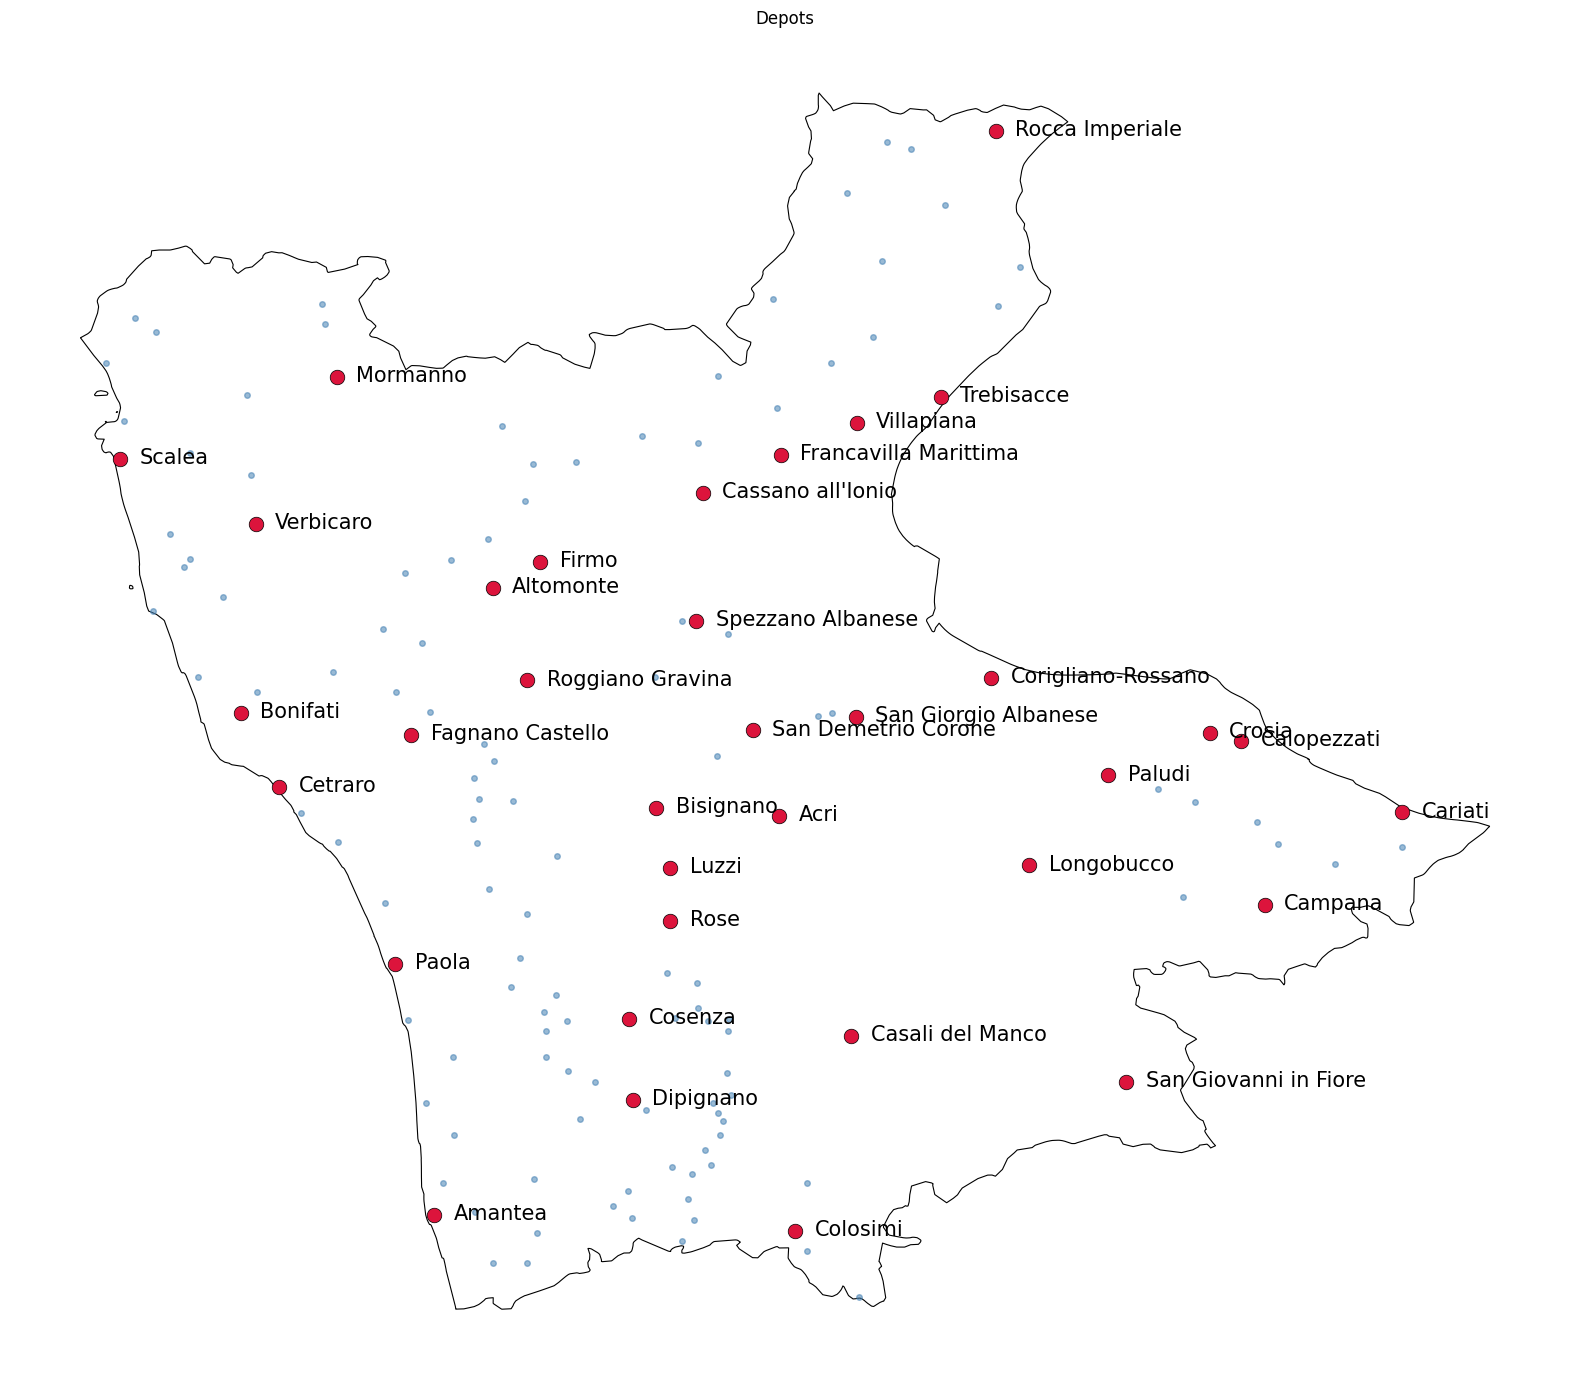

In [45]:
EPS, MIN_DEMAND = 15.0, 7

D = [[pair[1] for pair in row] for row in distance_duration_table] # we cluster by duration, thus we need to extract the durations from the already loaded table distance_duration_table


labels = DBSCAN(eps=EPS, min_samples=MIN_DEMAND, metric="precomputed").fit(D, sample_weight=w).labels_.tolist() # cluster the towns weighted by demand (w)
# then take the busiest town of each cluster as its depot
depots = []
for c in set(labels):
    if c == -1:
        continue
    best_node = None
    for i, label in enumerate(labels):
        if label != c:
            continue
        if best_node is None or w[i] > w[best_node]:
            best_node = i
    depots.append(best_node)

on_demand = [i for i in range(len(cities)) if i not in depots]

#----------- PLOT, AI MADE -----------
lat, lon = [], [] # we read the coordinates of the cities from the corresponding file
for line in open(path + "cities_coordinates.txt"): # again, for the format of the files, see the appendix "Appendix: Constructing the datasets" on the .pdf file or the omonimous section of this notebook
    if not line.strip(): # skip empty lines (the last one)
        continue
    a, b = line.split("(")[1].rstrip(")\n").split(", ")
    lat.append(float(a)); lon.append(float(b))

# province boundary
cosenza = gpd.read_file("https://raw.githubusercontent.com/openpolis/geojson-italy/master/geojson/limits_IT_provinces.geojson").query("prov_name == 'Cosenza'") # https://github.com/openpolis/geojson-italy is a crazy repository

fig, ax = plt.subplots(figsize=(20, 20))
cosenza.boundary.plot(ax=ax, color="black", linewidth=0.8)
ax.scatter([lon[i] for i in on_demand], [lat[i] for i in on_demand], s=16, color="steelblue", alpha=0.55, zorder=2)
ax.scatter([lon[i] for i in depots],    [lat[i] for i in depots],    s=110, color="crimson", edgecolor="black", linewidth=0.5, zorder=3)

texts = [ax.text(lon[i]+0.0175, lat[i]-0.0045, cities[i], fontsize=15, zorder=4) for i in depots]

ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title("Depots")
plt.show()

## Algorithm implementation in the offline setting

Here we report the code implementing the algorithmic solution described in the report.

In [46]:
def t_ij(i, j):
    return distance_duration_table[i][j][1] # travel time t_{ij} in minutes between cities i and j

def evaluate(T_prime, depot, Q, W, THETA, d, T0, T, people):
    """
    Basically, one simulation of the T_prime tour operated from "depot". Returns (feasible, z), where feasible is true if the tour does not trespass some of the constraints and z is the total delay of the customers of the tour.
    """
    t = T0; load = 0; c = depot; d_prime = 0 # starting time, empty vehicle at the start, service time of the stop, 0 for the depot
    S = {}; z = 0.0 # pick-up service time beginnings, accumulated delay
    for kind, nu, req in T_prime: # for each stop in the tour
        rid, origin, destination, tau = req
        t = t + d_prime + t_ij(c, nu) # getting to nu from current stop
        if kind == 'P': # pick-up city
            t = max(t, tau) # wait if early
            if t > tau + W:           return False, float('inf') # outside pick-up window
            if load + people > Q:     return False, float('inf') # overload
            load += people
            S[rid] = t # beginning of pick-up service (u_i)
        else: # delivery
            if t - (S[rid] + d) > t_ij(origin, destination) + THETA: # over maximum travel time
                return False, float('inf')
            load -= people
            z += (S[rid] - tau) + (t - tau - t_ij(origin, destination)) # pick-up delay+arrival delay
        c = nu; d_prime = d
    if T_prime and t + d_prime + t_ij(c, depot) > T0 + T: # getting back to the depot within the time window
        return False, float('inf')
    return True, z

def total_delay(routes, depots, Q, W, THETA, d, T0, T, people): # global objective: time delay of all customers
    return sum(evaluate(routes[k], depots[k], Q, W, THETA, d, T0, T, people)[1] for k in range(len(depots)))

# ---------- INSERTION ----------
def Insertion(requests, depots, *, Q=30, W=20, THETA=30, d=0, T0=6*60, T=4*60, PAX=1): # the asterisk ensures that the parameters after it are keyword only, so that they cannot be swapped by mistake
    routes = [[] for _ in depots] # initialization: K empty tours
    A = []; R = [] # lists of accepted/rejected requests
    for rid, o_name, dd_name, tau in requests: # process in the given order
        o = index[o_name]; dd = index[dd_name] # conversion dictionary from city names to indexes and vice-versa
        req = (rid, o, dd, tau)
        best_dz = float('inf'); best_k = None; best_route = None # Delta*, k*, T*
        for k, depot in enumerate(depots):
            Tk = routes[k]; L = len(Tk)
            _, z0 = evaluate(Tk, depot, Q, W, THETA, d, T0, T, PAX) # current tour cost
            for p in range(L + 1): # pick-up position insertion
                for q in range(p, L + 1): # delivery position insertion (>= pick-up one)
                    cand = Tk[:p] + [('P', o, req)] + Tk[p:q] + [('D', dd, req)] + Tk[q:]
                    ok, zc = evaluate(cand, depot, Q, W, THETA, d, T0, T, PAX)  # evaluate the route with the given insertion
                    if ok:
                        dz = zc - z0 # insertion cost
                        if dz < best_dz: # we consider the less costly insertion so far
                            best_dz = dz; best_k = k; best_route = cand
        if best_k is None:
            R.append(req) # no possible insertion: reject
        else:
            routes[best_k] = best_route; A.append(req) # accept less costly insertion overall
    return routes, A, R

# ---------- OPTIMIZATION ----------
def Optimization(requests, depots, N, *, Q=30, W=20, THETA=30, d=0, T0=6*60, T=4*60, PAX=1, seed=42): # the asterisk ensures that the parameters after it are keyword only, so that they cannot be swapped by mistake
    requests = list(requests) # work on a copy: the original list should not be reordered: the arrival order is meaningful
    rng = random.Random(seed)
    routes_star, A_star, R_star = Insertion(requests, depots, Q=Q, W=W, THETA=THETA, d=d, T0=T0, T=T, PAX=PAX) # initialization: we consider the arrival order
    z_star = total_delay(routes_star, depots, Q, W, THETA, d, T0, T, PAX)
    for _ in range(N): # we consider (only) N reshufflings
        for i in range(len(requests) - 1, 0, -1): # random permutation of the requests using the (optimized version of the) Fisher-Yates procedure. We are not interested in keeping the true arrival order, so we directly shuffle the original list
            j = rng.randint(0, i) # uniform integer in [0, i] (endpoints included)
            requests[i], requests[j] = requests[j], requests[i] # swap positions i and j
        routes, A, R = Insertion(requests, depots, Q=Q, W=W, THETA=THETA, d=d, T0=T0, T=T, PAX=PAX)
        z_val = total_delay(routes, depots, Q, W, THETA, d, T0, T, PAX)
        if (len(A) > len(A_star)) or (len(A) == len(A_star) and z_val < z_star): # we seek to increase the number of served people, then to improve the cost (we look for little total delay)
            routes_star, A_star, R_star, z_star = routes, A, R, z_val
    return routes_star, A_star, R_star, z_star
# ---------- string formatting ----------
def read(request):
    minutes = int(request[3])
    time = f"{minutes//60:02d}:{minutes%60:02d}"
    return f"{cities[request[1]]} -> {cities[request[2]]} @ {time}"

## Toy example

Here is the code to solve the toy example with the proposed implementation. In this case we assume the same parameters described in the section about the toy example present in the .pdf file. We first consider the insertion procedure only, which we know will yield only two accepted requests, and then the full insertion+optimization procedure.

In the latter, since there are few requests we manually enumerate all the arrival orders, without actually calling the `Optimization` function, which permutates randomically.

In [47]:
# toy: (id, origin, destination, tau_in_minutes)
toy = [
    (0, "Cosenza",           "Paola",        7*60),       # rho1, 7:00
    (1, "Marano Marchesato", "Castrolibero", 7*60 + 5),   # rho2, 7:05
    (2, "Cosenza",           "Castrolibero", 7*60 + 5),   # rho3, 7:05
    (3, "Bisignano",         "Acri",         7*60 + 20),  # rho4, 7:20
]
toy_depots = [index["Rende"], index["Acri"]]

# 1) Insertion only (considering arrival order)
routes, A, R = Insertion(toy, toy_depots, Q=2, W=20, THETA=20, d=0, T0=7*60, T=70, PAX=1)
print("Insertion only")
print("  accepted:", [read(r) for r in A])
print("  rejected:", [read(r) for r in R])
print("  z =", total_delay(routes, toy_depots, 2, 20, 20, 0, 7*60, 70, 1))

# 2) Insertion + Optimization. The instance is tiny, so we enumerate ALL 4! = 24 arrival orders

best = None
for order in permutations(toy):
    routes_o, A_o, R_o = Insertion(list(order), toy_depots, Q=2, W=20, THETA=20, d=0, T0=7*60, T=70, PAX=1)
    z_o = total_delay(routes_o, toy_depots, 2, 20, 20, 0, 7*60, 70, 1)
    if best is None or len(A_o) > len(best[1]) or (len(A_o) == len(best[1]) and z_o < best[3]):
        best = (routes_o, A_o, R_o, z_o)
routes, A, R, z = best

print("Insertion + (exhaustive) Optimization")
print("  accepted:", [read(r) for r in A])
print("  rejected:", [read(r) for r in R])
print("  z =", z)

Insertion only
  accepted: ['Cosenza -> Paola @ 07:00', 'Bisignano -> Acri @ 07:20']
  rejected: ['Marano Marchesato -> Castrolibero @ 07:05', 'Cosenza -> Castrolibero @ 07:05']
  z = 25.11400000000007
Insertion + (exhaustive) Optimization
  accepted: ['Marano Marchesato -> Castrolibero @ 07:05', 'Cosenza -> Castrolibero @ 07:05', 'Bisignano -> Acri @ 07:20']
  rejected: ['Cosenza -> Paola @ 07:00']
  z = 59.265000000000164


## Solution of the full problem in the offline setting

Here is the code to solve the full problem with the proposed implementation. Here we suppose to have vehicles with a capacity of 10 and set the shift window to the one described in the report: from 06:00 a.m. to 10:00 a.m. We first consider the insertion procedure and then the full insertion+optimization procedure. The following chunk takes approximately $3\text{min}$ to run:

In [48]:
# 1) Insertion only
fleet = [d for d in depots for _ in range(10)] # we simply (and stupidly) consider 10 vehicles for each depot
routes, A, R = Insertion(requests, fleet, Q=10, W=20, THETA=20, d=0, T0=6*60, T=4*60, PAX=1)
z = total_delay(routes, fleet, 10, 20, 20, 0, 6*60, 4*60, 1)
print("Insertion only")
print("  accepted:", [read(r) for r in A])
print("  rejected:", [read(r) for r in R])
# ---------- results ----------
print(f"  served {len(A)} / {len(requests)}  (rejected {len(R)})")
print(f"  total delay z = {z:.1f} min" + (f"  ({z/len(A):.2f} min per served)" if A else ""))

# 2) Insertion + Optimization (reshuffling)
routes, A, R, z = Optimization(requests, fleet, N=10, Q=10, W=20, THETA=20, d=0, T0=6*60, T=4*60, PAX=1)
print("Insertion + Optimization")
print("  accepted:", [read(r) for r in A])
print("  rejected:", [read(r) for r in R])
print("  z =", z)

# ---------- results ----------
print(f"served {len(A)} / {len(requests)} requests  (rejected {len(R)})")
print(f"total delay z = {z:.1f} min" + (f"  ({z/len(A):.2f} min per served customer)" if A else ""))

Insertion only
  accepted: ['San Marco Argentano -> Luzzi @ 06:12', 'Luzzi -> Castrolibero @ 07:35', 'Terranova da Sibari -> Pietrafitta @ 06:23', 'Rogliano -> Diamante @ 06:21', 'Bisignano -> Montalto Uffugo @ 08:12', 'Corigliano-Rossano -> Rende @ 07:07', 'San Lucido -> Dipignano @ 08:52', 'San Pietro in Guarano -> Cosenza @ 07:09', "Cassano all'Ionio -> Acri @ 08:08", 'Luzzi -> Corigliano-Rossano @ 07:19', 'Fagnano Castello -> Rende @ 08:02', "Corigliano-Rossano -> Cassano all'Ionio @ 08:00", 'Rende -> Paola @ 07:43', 'Scalea -> Cosenza @ 08:11', 'Luzzi -> Montalto Uffugo @ 07:13', 'Cetraro -> Rende @ 06:35', 'Paola -> Rende @ 08:27', 'Amendolara -> Cerisano @ 08:02', 'Scalea -> Rende @ 06:06', 'Rende -> Longobucco @ 07:12', 'San Lucido -> Bonifati @ 08:52', 'Diamante -> Cosenza @ 08:00', 'Villapiana -> Paola @ 07:19', 'San Marco Argentano -> Spezzano della Sila @ 08:00', 'Castrovillari -> San Lucido @ 06:49', 'Marano Marchesato -> Corigliano-Rossano @ 08:39', 'Altomonte -> Coriglia

## Simulations

### Online setting

The algorithm proposed works fine in the offline setting, but it is actually thought to work serving a web application in which registered users can make reservations. We can simulate the arrival of requests made by the users using a queue, which we here implement via a circular array:

In [18]:
class RequestsQueue:
    """
    Queue type class for the requests, implemented via circular array.
    """
    def __init__(self, capacity=500):
        self._requests=[None]*capacity #pre-allocated array with fixed initial capacity
        self._front=0 #front index
        self._size=0 #number of current present requests
        self._id=0 #progressive automatic id
        self._capacity=capacity

    def push(self, origin, destination, departure_time): #enqueue
        if self._size == self._capacity: #if the capacity is reached, resize
            print("Queue is full. Resizing...")
            self.resize()
        hours, minutes=departure_time.split(":")
        self._requests[(self._front + self._size)%self._capacity]=[self._id, origin, destination, int(hours)*60+int(minutes)]
        self._size += 1; self._id += 1
        return

    def pop(self): #dequeue
        if self._size==0:
            raise IndexError("Empty queue!")
        r = self._requests[self._front]
        self._requests[self._front]=None #empties the slot
        self._front=(self._front+1)%self._capacity #update front
        self._size-=1 #update size
        return r

    def resize(self):
        old_capacity = self._capacity
        temp = self._requests
        self._capacity = 2 * self._capacity
        self._requests = [None] * self._capacity
        for i in range(self._size):
            self._requests[i] = temp[(self._front + i) % old_capacity]
        self._front = 0

    def clear(self):
        self._size=0
        self._front=0
        return

    def is_empty(self):
        return self._size==0

    def is_full(self):
        return self._size==self._capacity

    def __len__(self):
        return self._size

    def __str__(self): #for the print method
        if not(self.is_empty()):
            print=""
            for i in range(self._size):
                j=(self._front + i) % self._capacity
                time = f"{self._requests[j][3] // 60:02d}:{self._requests[j][3] % 60:02d}"
                print+="id: "+str(self._requests[j][0])+", "+"source: "+str(self._requests[j][1])+", destination: "+str(self._requests[j][2])+" @ "+time+"\n"
            return print
        return ""

Here is the function we use to load the requests in the queue from the file `requests.txt`. We add a parameter to tell how many requests we want to be saved in the queue:

In [19]:
def load_queue(queue, path_file, limit=None):
    """
    Returns a RequestsQueue instance "queue" filled with the requests in the file path_file.
    It is built to work with the requests in the file requests.txt, thus the format it expects is:
    one request per line of the type 'origin->destination->Hour:Minutes')
    Optionally, load the first 'limit' many.
    """
    with open(path_file) as f:
        next(f) # skip the header
        i=0
        for line in f:
            if not line:
                continue
            origin, destination, departure = line.split("->")
            queue.push(origin, destination, departure)
            i+=1
            if limit is not None and limit==i:
                break
    return

We also have to (slightly) modify the `Insertion` function: indeed, in thie offlien setting this always stats from `K` empty tours, building a solution from scratch. This is possible because having the requests beforehand gives us the possibility to investigate the best order overall without having to accept or rejected requests without knowing how this will condition the overall solution. Online, each new request has to be placed into the plan already built for the previously accepted ones because we cannot discard these. The modification is in the new keyword `routes`. If this is not passed, the algorithm works exactly as before. In this way, the nre request is inserted independently of how many requests have already been accepted: this is the fast answer needed.

In [20]:
# ---------- INSERTION ----------
def Insertion(requests, depots, *, routes=None, Q=30, W=20, THETA=30, d=0, T0=6*60, T=4*60, PAX=1):
    if routes is None: # <<< CHANGED: seed from a given plan, or start empty
        routes = [[] for _ in depots] # initialization: K empty tours
    A = []; R = [] # lists of accepted/rejected requests
    for rid, o_name, dd_name, tau in requests: # process in the given order
        o = index[o_name]; dd = index[dd_name] # conversion dictionary from city names to indexes and vice-versa
        req = (rid, o, dd, tau)
        best_dz = float('inf'); best_k = None; best_route = None # Delta*, k*, T*
        for k, depot in enumerate(depots):
            Tk = routes[k]; L = len(Tk)
            _, z0 = evaluate(Tk, depot, Q, W, THETA, d, T0, T, PAX) # current tour cost
            for p in range(L + 1): # pick-up position insertion
                for q in range(p, L + 1): # delivery position insertion (>= pick-up one)
                    cand = Tk[:p] + [('P', o, req)] + Tk[p:q] + [('D', dd, req)] + Tk[q:]
                    ok, zc = evaluate(cand, depot, Q, W, THETA, d, T0, T, PAX)  # evaluate the route with the given insertion
                    if ok:
                        dz = zc - z0 # insertion cost
                        if dz < best_dz: # we consider the less costly insertion so far
                            best_dz = dz; best_k = k; best_route = cand
        if best_k is None:
            R.append(req) # no possible insertion: reject
        else:
            routes[best_k] = best_route; A.append(req) # accept less costly insertion overall
    return routes, A, R

The following function reproduces the "double dynamic" scheme on the queue proposed by Carotenuto and Martis. Requests are extracted one at a time from the queue, simulating their arrival over time. The modifies `Insertion` provides an irrevocable and fast accept/reject answer. Right after, in what should be the idle time before the next arrival, `Optimization` reshuffles the whole set of accepted requests. This is done taking into account only the previously accepted requests. The optimized solution is kept only if no previously accepted request is now rejected and the total delay is decreased.

In [21]:
def online_cm(queue, depots, *, N=10, Q=10, W=20, THETA=20, d=0, T0=6*60, T=4*60, PAX=1):
    routes = [[] for _ in depots] # this will store the current plan, which we store across arrivals
    accepted, rejected = [], []
    while not queue.is_empty():
        req = queue.pop() # simulation of how a request arrives over time
        # level 1: insert ONLY the new request into the current plan. Fast answer (O(K L^3))
        routes, served, _ = Insertion([req], depots, routes=routes, Q=Q, W=W, THETA=THETA, d=d, T0=T0, T=T, PAX=PAX)
        if served: # If feasible, accept. This is immediately told to the customer and irrevocable
            accepted.append(req)
            # level 2: between-arrival reshuffling of everything accepted. The best plan is kept
            r2, A2, _, z2 = Optimization(accepted[:], depots, N, Q=Q, W=W, THETA=THETA, d=d, T0=T0, T=T, PAX=PAX)
            if len(A2) == len(accepted) and z2 <= total_delay(routes, depots, Q, W, THETA, d, T0, T, PAX):
                routes = r2 # adopt only if it drops no previously accepted request and does not worsen z
        else:
            rejected.append(req) # infeasible -> rejected (irrevocably)
    return routes, accepted, rejected

Note that we are not able to simulate time passing, thus completed requests are never actually retired. The accepted set only grows and this corresponds to the worse case in our complexity analysis. The time of execution is therefore considerable.
In the followinf chunk, we exploit the discussed functions to run the actual simulation, considering only a subset of the requests and 3 vehicles per depot. Still, this takes approximately 2 minutes running.

In [24]:
fleet = [d for d in depots for _ in range(3)] # 3 vehicles per depot

queue = RequestsQueue()
load_queue(queue, path + "requests.txt", limit=200) # load a subset of the requests in the queue

hhmm = lambda t: f"{int(round(t))//60:02d}:{int(round(t))%60:02d}" # printer helper
routes, A, R = online_cm(queue, fleet, N=5, Q=10, W=20, THETA=20, d=0, T0=6*60, T=4*60, PAX=1)
z = total_delay(routes, fleet, 10, 20, 20, 0, 6*60, 4*60, 1)

# -------- PRINT THE RESULTS --------
print("Online simulation")
print(f"served {len(A)} / {len(A) + len(R)} requests  (rejected {len(R)})")
print(f"total delay z = {z:.1f} min" + (f"  ({z/len(A):.2f} min per served customer)" if A else ""))
print("  accepted:", [f"{r[1]} -> {r[2]} @ {hhmm(r[3])}" for r in A[:10]])
print("  rejected:", [f"{r[1]} -> {r[2]} @ {hhmm(r[3])}" for r in R[:10]])

Online simulation
served 160 / 200 requests  (rejected 40)
total delay z = 363.8 min  (2.27 min per served customer)
  accepted: ['San Marco Argentano -> Luzzi @ 06:12', 'Luzzi -> Castrolibero @ 07:35', 'Terranova da Sibari -> Pietrafitta @ 06:23', 'Rogliano -> Diamante @ 06:21', 'Bisignano -> Montalto Uffugo @ 08:12', 'Corigliano-Rossano -> Rende @ 07:07', 'San Lucido -> Dipignano @ 08:52', 'San Pietro in Guarano -> Cosenza @ 07:09', "Cassano all'Ionio -> Acri @ 08:08", 'Luzzi -> Corigliano-Rossano @ 07:19']
  rejected: ['Corigliano-Rossano -> Rende @ 08:50', 'Corigliano-Rossano -> Praia a Mare @ 07:32', 'Rocca Imperiale -> San Pietro in Guarano @ 07:49', 'Mangone -> Cosenza @ 09:20', 'Rende -> Torano Castello @ 09:17', 'Paola -> Rende @ 09:32', 'Amantea -> Rogliano @ 08:39', 'Grisolia -> Amantea @ 08:13', 'Saracena -> Castrovillari @ 09:23', 'Acri -> Rende @ 09:08']


To be able to do a fair comparison, we run the same requests in offline setting:

In [26]:
requests = []
with open(path + "requests.txt") as f:
    next(f)
    rid = 0
    for line in f:
        line = line.strip()
        if not line:
            continue
        origin, destination, departure = line.split("->")
        h, m = departure.split(":")
        requests.append((rid, origin, destination, int(h)*60 + int(m)))
        rid += 1
        if rid==200:
            break

fleet = [d for d in depots for _ in range(3)] # we simply (and stupidly) consider 3 vehicles for each depot

routes, A, R, z = Optimization(requests, fleet, N=5, Q=10, W=20, THETA=20, d=0, T0=6*60, T=4*60, PAX=1)
print("Insertion + Optimization")
print("  accepted:", [read(r) for r in A])
print("  rejected:", [read(r) for r in R])
print("  z =", z)

# ---------- results ----------
print(f"served {len(A)} / {len(requests)} requests  (rejected {len(R)})")
print(f"total delay z = {z:.1f} min" + (f"  ({z/len(A):.2f} min per served customer)" if A else ""))

Insertion + Optimization
  accepted: ['Montalto Uffugo -> Trebisacce @ 06:14', 'Cosenza -> Falconara Albanese @ 08:40', 'Scigliano -> Acri @ 06:03', 'Montalto Uffugo -> Cosenza @ 07:40', 'Amendolara -> Cerisano @ 08:02', 'Luzzi -> Acri @ 07:24', 'Luzzi -> Castrolibero @ 07:35', "Cassano all'Ionio -> Bisignano @ 07:06", 'Bonifati -> Corigliano-Rossano @ 06:05', 'Buonvicino -> Cosenza @ 07:18', 'Cetraro -> Rende @ 06:35', 'Rende -> Santa Maria del Cedro @ 08:10', 'Cosenza -> Rende @ 07:30', 'Trebisacce -> Acri @ 07:55', 'Castrovillari -> Castrolibero @ 06:34', 'Corigliano-Rossano -> Spezzano della Sila @ 06:58', 'Mendicino -> Rende @ 07:33', 'Paola -> San Marco Argentano @ 07:19', 'San Demetrio Corone -> Cetraro @ 07:59', 'Cosenza -> Rende @ 08:37', 'Cosenza -> Casali del Manco @ 07:31', 'Mandatoriccio -> Campana @ 06:35', 'Paola -> Rende @ 06:32', 'San Pietro in Guarano -> Montalto Uffugo @ 06:57', 'Scalea -> Rende @ 06:06', 'San Lucido -> Bonifati @ 08:52', 'Castrolibero -> Cosenza @ 0

### Running time versus number of requests

Here we measure how the running time of the two settings (online and offline) grows with the number of requests. We let the number of requests range in a certain interval and measure the time it takes for each of the algorithms in both settings to run. Then we plot the results. We keep the same fleet and the same parameters. The following chunk of code takes approximately $30\text{sec}$ to run.

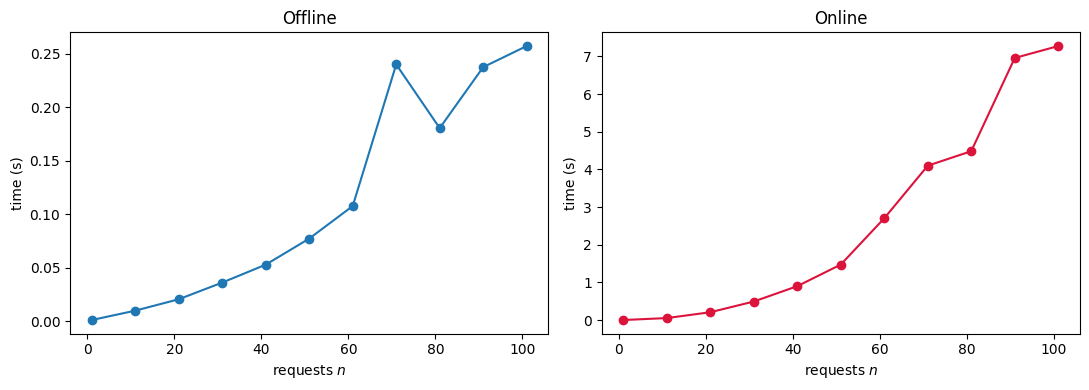

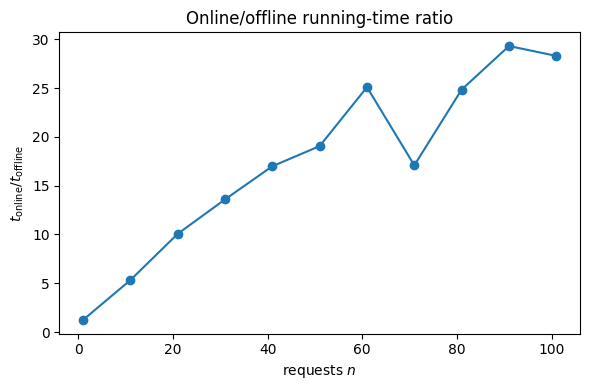

In [27]:
def retrieve(path_file, n):
    reqs = []
    with open(path_file) as f:
        next(f); rid = 0
        for line in f:
            line = line.strip()
            if not line: continue
            o, d, dep = line.split("->"); h, m = dep.split(":")
            reqs.append((rid, o, d, int(h)*60+int(m))); rid += 1
            if rid == n: break
    return reqs

fleet  = [d for d in depots for _ in range(3)]
Ns     = list(range(1, 102, 10))

t_off, t_on, acc_off, del_off, acc_on, del_on = [], [], [], [], [], []
for n in Ns:
    reqs = retrieve(path + "requests.txt", n)
    t0 = time.perf_counter()
    routes, A, R, z = Optimization(reqs[:], fleet, N=1, Q=10, W=20, THETA=20, d=0, T0=6*60, T=4*60, PAX=1)
    t_off.append(time.perf_counter()-t0)
    acc_off.append(len(A)/n); del_off.append(z/len(A) if A else 0)

    q = RequestsQueue(); load_queue(q, path + "requests.txt", limit=n)
    t0 = time.perf_counter()
    routes, A, R = online_cm(q, fleet, N=1, Q=10, W=20, THETA=20, d=0, T0=6*60, T=4*60, PAX=1)
    t_on.append(time.perf_counter()-t0)
    z_on = total_delay(routes, fleet, 10, 20, 20, 0, 6*60, 4*60, 1)
    acc_on.append(len(A)/n)
    del_on.append(z_on/len(A) if A else 0)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4))
axL.plot(Ns, t_off, "o-");                axL.set(title="Offline", xlabel="requests $n$", ylabel="time (s)")
axR.plot(Ns, t_on, "o-", color="crimson"); axR.set(title="Online",  xlabel="requests $n$", ylabel="time (s)")
plt.tight_layout(); plt.show()
plt.figure(figsize=(6,4))
plt.plot(Ns, [on/off for on, off in zip(t_on, t_off)], "o-")
plt.xlabel("requests $n$"); plt.ylabel(r"$t_\mathrm{online}/t_\mathrm{offline}$")
plt.title("Online/offline running-time ratio"); plt.tight_layout(); plt.show()

We can observe that both curves seems to grow more than linearly. This is to be expected because despite the different degrees in complexity in $n$, since the fleet is kept fixed the length of the tours (a quantity which we take into account with L in the complexity analysis) increases, and the factor $L^3$ in the complexity dominates.

What really matters is that the online time lies far above the offline one and grows faster: their ratio increases roughly linearly with $n$, as the last plot shows.

In the previous chunk we also stored information on the acceptance rate in the two settings, which we now plot:

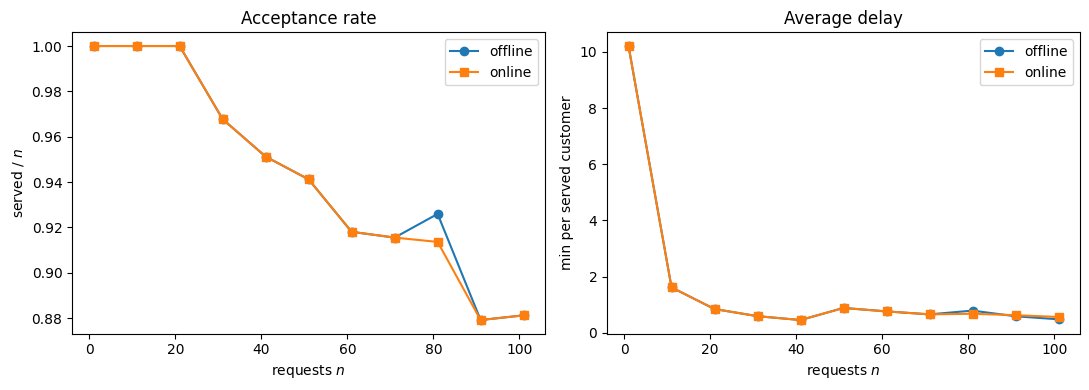

In [28]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(Ns, acc_off, "o-", label="offline"); a1.plot(Ns, acc_on, "s-", label="online")
a1.set(title="Acceptance rate", xlabel="requests $n$", ylabel="served / $n$"); a1.legend()
a2.plot(Ns, del_off, "o-", label="offline"); a2.plot(Ns, del_on, "s-", label="online")
a2.set(title="Average delay", xlabel="requests $n$", ylabel="min per served customer"); a2.legend()
plt.tight_layout(); plt.show()

and as we expect, it does not happen that the acceptance rate of the offline mode stays below the one in the online mode, and the same thing tends to happen (even though it is more erratic) happens for the average delay of customers.

### Fleet size versus acceptance

We are now interested in showing how the fleet sizing impacts on the number of accepted requests and the average delay per customer. We consider only the offline setting and a naive assignment of the vehicles ($n$ per depot), just o get a grasp on what is the relationship:

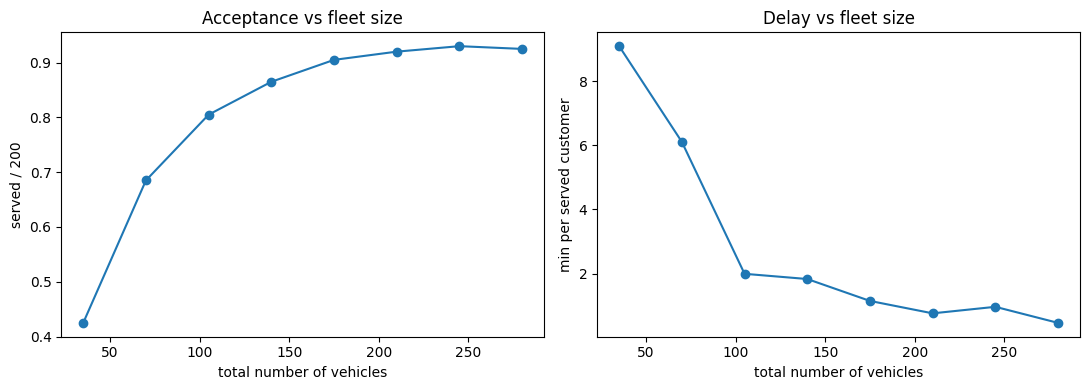

In [29]:
reqs = retrieve(path + "requests.txt", 200)
per_depot = list(range(1, 9))
acc, dly = [], []
for v in per_depot:
    fl = [d for d in depots for _ in range(v)]
    routes, A, R, z = Optimization(reqs[:], fl, N=1, Q=10, W=20, THETA=20, d=0, T0=6*60, T=4*60, PAX=1)
    acc.append(len(A)/len(reqs)); dly.append(z/len(A) if A else 0)

xs = [v*len(depots) for v in per_depot]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(xs, acc, "o-"); a1.set(title="Acceptance vs fleet size", xlabel="total number of vehicles", ylabel="served / 200")
a2.plot(xs, dly, "o-"); a2.set(title="Delay vs fleet size",      xlabel="total number of vehicles", ylabel="min per served customer")
plt.tight_layout(); plt.show()

As we might expect, increasing the fleet size increases the number of requests which the system is able to accept, even though the assignment of the vehicles is very naive. Obviously, also the delay drop. An important thing to notice is that even increasing the fleet indefinitely it does not seem that we are able to serve all customers and to arbitrarily lower the average delay per customer. This is for two reasons:
- there are some requests which are intrinsically difficult, perhaps "impossible";
- the depots are fixed and some requests might have as departure place some city whose closest depot is not really that close. It is thus inevitable to accumulate some delay.  

## Appendix: Constructing the datasets

In this appendix, we will see how the files *"cities_coordinates.txt"* and *"distance-duration_table.txt"* have been created. These store respectively:
- the coordinates of all the 150 municipalities in province of Cosenza (in the format `City: (latitude, longitute)`);
- the distances (in kilometers) and the durations (in minutes) between the `i`-th city from the `j`-th, with `i, j` ranging from 1 to 150, in the following format: $$ \begin{aligned} &\text{City}_1: (\text{distance}_{1\,2},\text{duration}_{1\,2}); (\text{distance}_{1\,3},\text{duration}_{1\,3}); \dots, (\text{distance}_{1\,150},\text{duration}_{1\,150}) \\ &\text{City}_2: (\text{distance}_{2\,3},\text{duration}_{2\,3}); (\text{distance}_{2\,4},\text{duration}_{2\,4}); \dots, (\text{distance}_{2\,150},\text{duration}_{2\,150}) \\ &\vdots \\ &\text{City}_{149}: (\text{distance}_{149\,150},\text{duration}_{149\,150}) \\ &\text{City}_{150}: \; \end{aligned} $$ where we only store the distances of $\text{City}_i$ with $i\in\{1,\dots,150\}$ from $\text{City}_j$ with $j\in\{i,\dots,150\}$ because we are assuming that if $\text{City}_i$ is $d$ kilometers distant from $\text{City}_j$, then $\text{City}_j$ is $d$ kilometers distant from $\text{City}_i$ and a similar reasoning applies for the duration.

The first thing to do is to retrieve all cities in the province of Cosenza. We can do this by exploiting the website [istat.it](https://www.istat.it/) of the national statistical institute of Italy, which stores various data regarding Italy. In particular, the following [link](https://www.istat.it/storage/codici-unita-amministrative/Elenco-comuni-italiani.csv) can be used to download a .csv file containing all municipalities in Italy, with information to the province to which they belong. Thus we can extract the municipalities in the province of Cosenza in the following way:


In [30]:
def get_city():
    """
    Return the list of municipalities of the Province of Cosenza
    """
    cities = []
    with open(path + "List-of-Italian-municipalities.csv", encoding="latin-1") as f:
        reader = csv.reader(f, delimiter=";")
        next(reader)                                       # skip the header row
        for row in reader:
            if row[2].strip() == "078":                    # column 2=codice provincia; 078=Cosenza
                cities.append(row[6].strip())              # column 6=Denominazione in italiano
    return cities

cities = get_city()

this is a very quick operation since the function just reads the provided file. We can see the results here:

In [31]:
cities

['Acquaformosa',
 'Acquappesa',
 'Acri',
 'Aiello Calabro',
 'Aieta',
 'Albidona',
 'Alessandria del Carretto',
 'Altilia',
 'Altomonte',
 'Amantea',
 'Amendolara',
 'Aprigliano',
 'Belmonte Calabro',
 'Belsito',
 'Belvedere Marittimo',
 'Bianchi',
 'Bisignano',
 'Bocchigliero',
 'Bonifati',
 'Buonvicino',
 'Calopezzati',
 'Caloveto',
 'Campana',
 'Canna',
 'Cariati',
 'Carolei',
 'Carpanzano',
 "Cassano all'Ionio",
 'Castiglione Cosentino',
 'Castrolibero',
 'Castroregio',
 'Castrovillari',
 'Celico',
 'Cellara',
 'Cerchiara di Calabria',
 'Cerisano',
 'Cervicati',
 'Cerzeto',
 'Cetraro',
 'Civita',
 'Cleto',
 'Colosimi',
 'Cosenza',
 'Cropalati',
 'Crosia',
 'Diamante',
 'Dipignano',
 'Domanico',
 'Fagnano Castello',
 'Falconara Albanese',
 'Figline Vegliaturo',
 'Firmo',
 'Fiumefreddo Bruzio',
 'Francavilla Marittima',
 'Frascineto',
 'Fuscaldo',
 'Grimaldi',
 'Grisolia',
 'Guardia Piemontese',
 'Lago',
 'Laino Borgo',
 'Laino Castello',
 'Lappano',
 'Lattarico',
 'Longobardi',
 'Lo

Now we need to *geocode* the cities, i.e. actually write the file "*cities_coordinates.txt*" described above (before running, read below. Maybe you do not want to waste time):

In [ ]:
# Empties the files "cities_coordinates.txt" before actually creating it to avoid overwriting in the case one wants to try the code
open(path+"cities_coordinates.txt", "w", encoding="utf-8").close()

def geocode_cities(cities):
    """
    Geocode the cities passed as argument (supposing it is a list) using geopy.geocoders' Nominatim. Check: https://geopy.readthedocs.io/en/stable/, https://nominatim.org/release-docs/develop/api/Overview/
    Saves all city names and coordinates in a single .txt file.
    """

    # A different Nominatim agent than the default one must be used to avoid 403 and 429 errors, check: https://geopy.readthedocs.io/en/stable/#nominatim
    # Instance of Nominatim class
    geocoder = Nominatim(user_agent="Academic project", timeout=10)

    for city in cities:
        # Construct query based on the city passed as argument. See https://nominatim.org/release-docs/develop/api/Search/ for query construction documentation
        query = f"{city}, Cosenza, Calabria, Italia"

        # Use the geocode() method to get latitude and longitude of the location. Check: https://geopy.readthedocs.io/en/stable/#geopy.geocoders.Nominatim.geocode
        location = geocoder.geocode(query)

        # Creating the file with the cities and the respective coordinates. Using "with" for automatic closure of the file. Check: https://www.geeksforgeeks.org/python/with-statement-in-python/
        with open(path+"cities_coordinates.txt", "a", encoding="utf-8") as f:
            f.write(f"{city}: ({location.latitude}, {location.longitude})\n")
        time.sleep(10)
geocode_cities(cities)

Note that once the access to the personal Google Drive storage is granted, the previous code creates the "*cities_coordinates.txt*" file inside the Drive folder specified in the variable `path`. `Nominatim` is the geocoder for OpenStreetMap data, all documentation is in the sites indicated as comments in the code. In particular, the point on Earth's surface individuated by the returned coordinates corresponds, for each city, to the **centroid** of the administrative region of the city itself, as it is written [here](https://nominatim.org/release-docs/latest/api/Output/) (search for **centroid** in the webpage). This corresponds to the point whose coordinates are the averages of the coordinates of the points which fall inside the polygon representing said administrative region.

This chunk of code takes a long time running (~25 minutes). Indeed, a pause of 10 seconds between an API request (see the `geocode_city` function) and another one is needed (otherwise the server gives bad gateway!) and since there are:

In [32]:
len(cities)

150

cities in total, $150\cdot 10\text{s}\approx 25\text{min}$.

Now we create the file "*distance-duration_table.txt*" described above:

In [35]:
def distance_duration_table():
    """
    Build a triangular distance-duration table:
    - first row:  (distance, duration) pairs of the 1st city in "cities_coordinates.txt" from the 2nd, 3rd, ... up to the 150th, couples separated by a semicolon
    - second row: (distance, duration) pairs of the 2nd city from the 3rd, 4th, ... up to the 150th, couples separated by a semicolon
    - ...
    - 150-th row: empty
    Each line stores "(distance, duration); (distance, duration); ..." for the upper triangle only, assuming symmetry of both distance and duration. Distances are in kilometers,
    durations in minutes.
    Saves the result to "distance-duration_table.txt". The table service of the OSRM project is used, check: https://project-osrm.org/docs/v26.5.0/http#table-service.
    The OSRM "table" service returns the whole {sources}×{destinations} matrix in a single request, and with the specification annotations=distance,duration it returns the
    distances and the durations matrices at once. To explain how this code works, consider the following toy example:
    - imagine just 4 cities [0,1,2,3] and a max of, say, 4 coordinates per request. Split into two blocks: A=[0,1] and B=[2,3].
    - suppose you need values for every pair i<j. These fall into 3 groups: inside A: (0,1), inside B: (2,3), from A to B: (0,2), (0,3), (1,2), (1,3)
    - one thus needs 3 requests in total:
      A with A returns a 2×2 matrix containing only the pair (0,1) (recall that for each city we just store its
      relation to the cities subsequent to it in "cities_coordinates.txt", assuming symmetry);
      B with B (same as before) containing only (2,3);
      A with B sends the coords of [0,1,2,3] (A+B concatenated) requesting cities in A as sources and cities in B
      as destinations. The returned 2×2 matrix gives 0→2, 0→3, 1→2, 1→3.
    In our case, we have 150 cities. We use blocks of 50 because the cap on the max coords per request is 100 (2*50).
    We end up with 3 blocks => 3 "block with itself" calls + 3 cross calls (block 1 with 2,3; block 2 with 3) => 6 API calls in total.
    """
    # Read "city": (latitude, longitude) from "cities_coordinates.txt"
    coords = {}
    with open(path+"cities_coordinates.txt", "r", encoding="utf-8") as f:
        cities = []
        for line in f:
            line = line.strip()
            city, rest = line.split(": (", 1)
            rest = rest.rstrip(")")
            lat_str, lon_str = rest.split(", ")
            coords[city] = (float(lat_str), float(lon_str))
            cities.append(city)

    # Blocks of 50 (server cap is 100 coords => 2*50): 0-49, 50-99, 100-149
    blocks = [list(range(b, min(b + 50, 150))) for b in range(0, 150, 50)]

    # 150×150 matrices of zeros, one for distances and one for durations
    dist = [[0.0] * 150 for _ in range(150)]
    dur  = [[0.0] * 150 for _ in range(150)]

    base_query = "https://router.project-osrm.org/table/v1/driving/"

    for block in range(len(blocks)):
        for i in range(block, len(blocks)):
            A = blocks[block]
            B = blocks[i]
            if block == i:
                # Case block paired with itself
                pts = ";".join(f"{coords[cities[k]][1]},{coords[cities[k]][0]}" for k in A)
                query = f"{base_query}{pts}?sources=all&destinations=all&annotations=distance,duration"
            else:
                # Case block paired with another block
                pts = ";".join(f"{coords[cities[k]][1]},{coords[cities[k]][0]}" for k in A + B)
                src = ";".join(str(k) for k in range(len(A)))
                dst = ";".join(str(len(A) + k) for k in range(len(B)))
                query = f"{base_query}{pts}?sources={src}&destinations={dst}&annotations=distance,duration"

            r = requests.get(query)
            data = r.json()
            distances = data["distances"]   # meters
            durations = data["durations"]   # seconds

            # Map the returned matrices back to the global upper-triangle ones
            for row_ext, row_int in enumerate(A):
                for col_ext, col_int in enumerate(B):
                    if row_int < col_int:
                        dist[row_int][col_int] = round(distances[row_ext][col_ext] / 1000, 3)  # km
                        dur[row_int][col_int]  = round(durations[row_ext][col_ext] / 60, 3)     # minutes
            time.sleep(10)

    # Write on the file
    with open(path+"distance-duration_table.txt", "w", encoding="utf-8") as file:
        for i in range(150):
            pairs = [f"({dist[i][j]}, {dur[i][j]})" for j in range(i + 1, 150)]
            file.write("; ".join(pairs) + "\n")

distance_duration_table()

This chunk takes approximately $1\text{min}$ to run, which really is not that much. This is thanks to the `table` service provided by the OSMR project developers (praise be to them!) that allows to evaluate the (by car) distance and duration of the travel between multiple cities (both as sources and destinations) in a single API call. The real bottleneck is in fact the `time.sleep(10)` command in the nested loop (see the code above) - which is needed in order to avoid server overload -, but being able to evaluate the distance between multiple cities (both as sources and destinations) in a single API call allows to do less requests (in particular, given the chunk size - see the comments in the code and in particular the last line in the description of the function -, there are 6 API calls, thus $6\cdot 10\text{s}=1\text{min}$).

Now we turn to the problem of generating the requests to run our simulations and validate our model. Using the model discussed in the PDF, we need to build the file `cities_data.txt`. We start with including the data about population.

The data about the population can be downloaded [here](https://demo.istat.it/app/?l=it&a=2026&i=POS) in the section "Area download" and searching for "Cosenza". A .csv file containing data about the updated population of all cities in the province of Cosenza will be provided. Analyzing the file, one can see that the age value `999` is used as a flag for "total" values of the data:

In [ ]:
rows_out = []
with open(path+"Population.csv", encoding="utf-8-sig") as f:
    reader = csv.reader(f, delimiter=";")              # opening the file with a text editor and looking at the raw bytes, one can see that ";" is used as delimiter
    next(reader)
    next(reader)                                       # skip the first two (headers) rows
    for row in reader:
        if len(row)!=6:                                # skip the final note line containing "Nota: lo stato civile è in corso di validazione."
            continue
        if(int(row[2])==999):                          # exploit the flag value to identify rows containing total information
            comune=row[1]
            tot=int(row[5])
            rows_out.append((comune.strip(), tot))

with open(path+"cities_data.txt", "w", encoding="utf-8") as f:
    f.write("#City;population;railway;university;high schools\n") # begin to write the file
    for name, pop in rows_out:
        f.write("%s;%d;0;0;0\n" % (name, pop))

In this way, we have created the `cities_data.txt` inserting an header row which functions as legend for the content of the file, telling us what the numbers separated by the semicolon mean (read comment). To be more precise, the elements of the rows of the file separated by a semicolon mean the following (in order):
- name of the city;
- population of the city;
- integer values from 0 to 4 based on RFI's (Rete Ferroviaria Italiana) classification (see below);
- 1 if a university is in the city, 0 otherwise;
- an integer counting how many high schools are in the city;
- 1 if an airport is in the city.

Note that we initialized the columns `railway`, `university`, and `high schools` to the value 0 for all cities. This is because the data about columns 3-5 have been hand-written. In particular:
- the `railway` column has been retrieved from [this site](https://www.rfi.it/it/stazioni.html) after having selected the "Lista" option and the region of interest (Calabria) as well as the province of interest, following the classification of RFI on the importance of the stations (and signaling the absence of railway stations) with the conversion: `NO RAILWAY STATION`->`0`, `LOCAL`->`1`, `LOCAL PLUS`->`2`, `PLUS`->`3`, `MAJOR`->`4` (attention to the fact that RFI signals a `LOCAL` station in Corigliano and a `LOCAL PLUS` in Rossano. Since the two cities merged and apparently the RFI site has not been updated, we will flag Corigliano-Rossano as a `LOCAL-PLUS` hub);
- there is only `1` university in the province of Cosenza, as it can be retrieved from [this site](https://www.mur.gov.it/it/aree-tematiche/universita/le-universita/universita-statali) (official, by the Italian Ministry of University and Research MUR) and [this site](https://it.wikipedia.org/wiki/Lista_delle_universit%C3%A0_in_Italia) (unofficial, a Wikipedia page);
- the number of high schools per city has been retrieved from [this site](https://unica.istruzione.gov.it/sic) (official, by the Italian Ministry of Education and Merit MIM) after having selected "Ricerca avanzata" (Advanced research), "Cerca per: Regione, provincia o comune" (Search for: Region, province or municipality), "Regione: CALABRIA" (Region: Calabria), "Provincia: Cosenza" (Province: Cosenza), "Comune: Tutte le opzioni" (Municipality: All the options), "Tipo di istruzione: Scuola secondaria di II grado" (Education level: high school), "Percorso: Tutte le opzioni" (Path: All the options), "Tipologia scuola: Statale Paritaria" (Type of school: Statal Equalized, tick both options). We can see that this research yields 172 found high schools, but from this we decided to exclude the "Scuole serali". Furthemore, for each "Istituto", institute, we count every site/school. Artificial Intelligence (specifically, Claude Opus 4.8 max) has been used to automatize this process.

Furthermore, notice that `Population.csv` has the cities in alphabetical order, which contrast with the order that we have in `cities_coordinates.txt` (and thus also in `distance-duration_table.txt`): this is because in the generation of `cities_coordinates.txt` an [istat.it](https://www.istat.it/) dataset in which `Casali del Manco` and `Corigliano-Rossano` where respectively second-to-last and last element was used. To be consistent with the ordering so far, the rows in `cities_data.txt` corresponding to these two municipalities have been moved to the bottom.
Running the following code:

In [ ]:
total = 0
with open(path+"cities_data.txt", encoding="utf-8") as f:
    next(f)  # skip header
    for line in f:
        line = line.strip()
        if line:
            total += int(line.split(";")[4])
print("Total high schools:", total)

Total high schools: 132


it can be seen that 132 high schools have been individuated by said AI model.
To generate our observations, we will sample from the probability distribution:
$$\left(p_{ij}\right)_{i,j=1}^{150}$$
where $p_{ij}$ is the probability that a request has as source city $i$ and as destination city $j$. We will use
$$
p_{ij}=\frac{T_{ij}}{\sum\limits_{k\neq l}T_{kl}},
$$
where $T_{ij}$ is the magnitude of the migratory flow from city $i$ to city $j$ which, as said on the PDF (more information about the model and the parameters there), can be approximated by:
$$
T_{ij}=m_im_jf(r_{ij}),
$$
where $m_i$ and $m_j$ are the masses of cities $i$ and $j$ respectively and $f(r_{ij})$ is a factor accounting for the distance between city $i$ and city $j$, $r_{ij}$.
We suppose:
- $T_{ii}=0\,\forall\,i$, since we are concerned with inter-urban travels;
- $T_{ij}=T_{ji}$. This is reasonable because we are dealing with provincial, daily transportation;
- the masses are a function of all the indicators we have found and added to the `city_data.txt` file. In particular, we could imagine a relation of the type: $$m_i=P_i+25000U_i+200H_i+500R_i$$ i.e., the mass of a city is equal to its population plus the number of people that a university brings ($U_i$ is the indicator that city $i$ has a university in it. UniCal has 23 thousand student circa and 1500 workers circa, thus the 25 thousand value) plus the number of people that a high school brings ($H_i$ is the counter of high schools of city $i$. Since there are 89023 high school students in the province of Cosenza as it can be seen [here](https://osservatorio.regione.calabria.it/esplora-i-dati/numeri-del-sistema-scolastico/alunni/analisi-per-territorio.php), dividing by the 132 high schools which we have added before we get that a high school in Calabria approximately accounts for $89023/132\approx670$ students. Supposing that $30%$ of them need to travel, we get $30\%\cdot670\approx 200$ number) plus the number that a railway station of level $R_i$ brings (it can be seen [here](https://www.rfi.it/it/stazioni/pagine-stazioni/le-nostre-stazioni-classificazione-numeri-e-performance-che-le-identificano/i-dati-di-frequentazione-delle-stazioni.html) that each level corresponds to an increase of approximately $500$ people per day on average);
- that the decay in the distance is exponential, i.e. $$f(r_{ij})=\exp\{-r_{ij}/r_m\},$$ where $r_m$ is the order of a typical trip in the province in kilometers, for example the mean distance between two municipalities $\approx79.42\text{km}$ (see next chunk of code).

In [ ]:
total = count = 0
with open(path+"distance-duration_table.txt", encoding="utf-8") as f:
    for line in f:
        for cell in line.split(";"):
            cell = cell.strip()
            if cell:
                total += float(cell.strip("()").split(",")[0])
                count += 1
print(total / count)

79.42444161073824


We can now write the code to compute the probabilities and finally sample from them. We do so by reading the necessary information - described above - from the `cities_data.txt` file, constructing again the matrices of road distances and durations from the `distance-duration_table.txt` file because we need `np` objects to run the methods of the library, obtaining the migratory flows as the model defined above prescribes and normalizing by the total flow.

We finally draw $1000$ origin-destination pairs from the distribution of probability thus constructed (fixing a seed for reproducibility).

For the requested departure time, we sample uniformly in $[T_0,\ T_0+T-t_{ij}]$ — in minutes, $[360,\ 600-t_{ij}]$, i.e. the 6:00-10:00 shift — so that every generated request can, at least in principle, be completed within the shift. The (rare) pairs whose direct travel time alone exceeds the shift are discarded, and sampling simply continues - in the `while` cycle - until exactly $N$ admissible requests have been generated.

Each request is written to `requests.txt` as a line of the form `Source->Destination->Requested time`, below the header `Source->Destination->Departure time`.

In [40]:
W_UNI, W_HS, W_RAIL = 25000, 200, 500

P = np.zeros(150)
U = np.zeros(150)
H = np.zeros(150)
R = np.zeros(150)
names = np.empty(150, dtype=object)
with open(path+"cities_data.txt", encoding="utf-8") as f:
    next(f)
    i = 0
    for line in f:
        line = line.strip()
        if not line:
            continue
        names[i], P[i], R[i], U[i], H[i] = line.split(";")
        i += 1
n = len(P)

m = P + W_UNI*U + W_HS*H + W_RAIL*R

r   = np.zeros((n, n))
dur = np.zeros((n, n))
rows = [ln for ln in open(path+"distance-duration_table.txt", encoding="utf-8") if ln.strip()]
for i, line in enumerate(rows):
    for k, cell in enumerate(c for c in line.split(";") if c.strip()):
        j = i + 1 + k
        distance, duration = cell.strip().strip("()").split(",")
        r[i, j]   = r[j, i]   = float(distance)
        dur[i, j] = dur[j, i] = float(duration)

r_m = r[np.triu_indices(n, 1)].mean()
T = np.outer(m, m) * np.exp(-r / r_m)
np.fill_diagonal(T, 0.0)
Pij = T / T.sum()

N, SEED = 1000, 42
rng = np.random.default_rng(SEED)

START, END = 6*60, 10*60
hhmm = lambda t: f"{int(round(t))//60:02d}:{int(round(t))%60:02d}"

p = Pij.ravel()
with open(path+"requests.txt", "w", encoding="utf-8") as out:
    out.write("Source->Destination->Departure\n")
    kept = 0
    while kept < N:                                   # keep sampling until N requests are written
        draws = rng.choice(n*n, size=N-kept, p=p)     # top-up batch: draw as many pairs as are still missing
        for k in draws:
            s, d = k // n, k % n
            latest = END - dur[s, d]
            if latest < START:                        # infeasible pair: discard, the while loop will re-draw
                continue
            dep = rng.uniform(START, latest)
            out.write(f"{names[s]}->{names[d]}->{hhmm(dep)}\n")
            kept += 1